DBSCAN Clustering Algorithm
Density-Based Spatial Clustering of Applications with Noise

WHAT IS DBSCAN?
DBSCAN is a clustering algorithm that groups together points that are
closely packed together, marking points in low-density regions as outliers.

KEY CONCEPTS:
1. Epsilon (ε): Maximum distance between two points to be neighbors
2. MinPts: Minimum number of points to form a dense region (cluster)
3. Core Point: Point with at least MinPts neighbors within epsilon
4. Border Point: Point within epsilon of a core point but not core itself
5. Noise Point: Point that is neither core nor border (outlier)

HOW TO CHOOSE EPSILON:
Use K-distance graph (elbow method):
- Calculate distance to k-th nearest neighbor for each point
- Sort and plot these distances
- Look for "elbow" in the graph - that's your epsilon value

DBSCAN CLUSTERING DEMONSTRATION

Dataset created:
Total points: 160
Cluster 1: 50 points around (2, 2)
Cluster 2: 50 points around (8, 8)
Cluster 3: 50 points around (2, 8)
Noise: 10 random points

STEP 1: FINDING OPTIMAL EPSILON

Plotting k-distance graph...
Look for the 'elbow' point in the graph
The y-value at the elbow is your optimal epsilon


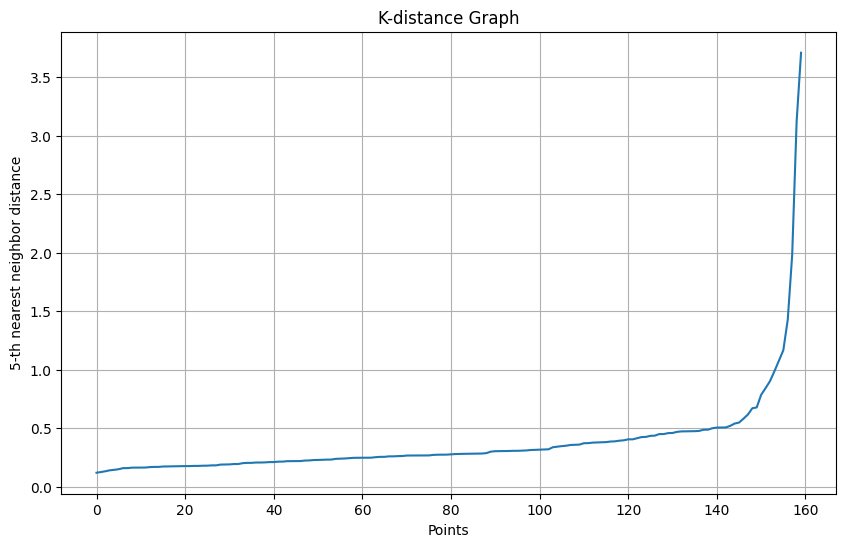


STEP 2: APPLYING DBSCAN

DBSCAN Parameters:
Epsilon (ε): 0.5
MinPts: 5

STEP 3: RESULTS

Number of clusters found: 3
Number of noise points: 11
Cluster 0: 50 points
Cluster 1: 51 points
Cluster 2: 48 points

STEP 4: VISUALIZATION


C:\Users\singh\AppData\Local\Temp\ipykernel_1616\955201256.py:138: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(xy[:, 0], xy[:, 1],


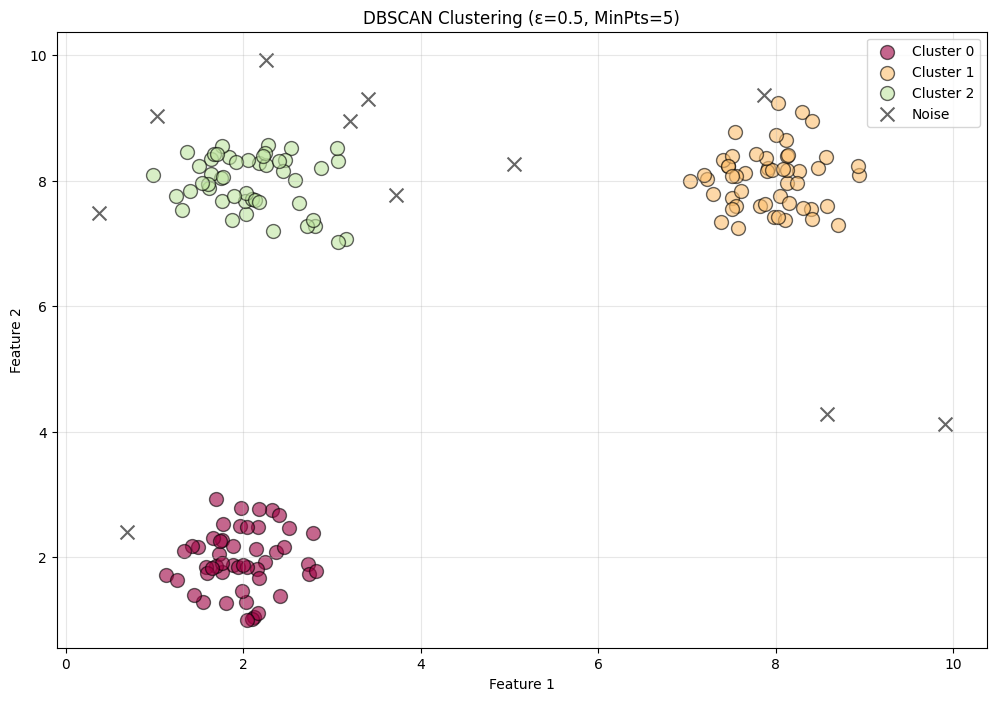


HOW DBSCAN WORKS

1. For each point, find all neighbors within epsilon distance

2. Classify points:
   - Core Point: Has >= MinPts neighbors (including itself)
   - Border Point: Within epsilon of a core point, but not core
   - Noise Point: Neither core nor border (outlier)

3. Form clusters:
   - Start with a core point
   - Add all reachable core points to the cluster
   - Add border points connected to these core points
   - Repeat for all unvisited core points

4. Mark remaining points as noise

ADVANTAGES:
✓ Finds clusters of arbitrary shape
✓ Automatically detects outliers
✓ No need to specify number of clusters
✓ Works well with spatial data

DISADVANTAGES:
✗ Sensitive to epsilon and MinPts parameters
✗ Struggles with varying density clusters
✗ Not suitable for high-dimensional data


REAL-WORLD EXAMPLE: CUSTOMER SEGMENTATION

Customer Dataset:
   Annual_Income  Spending_Score
0   54967.141530       30.051135
1   48617.356988       27.654129
2   56476.885381       15.846293
3

C:\Users\singh\AppData\Local\Temp\ipykernel_1616\955201256.py:237: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(customer_data[mask]['Annual_Income'],


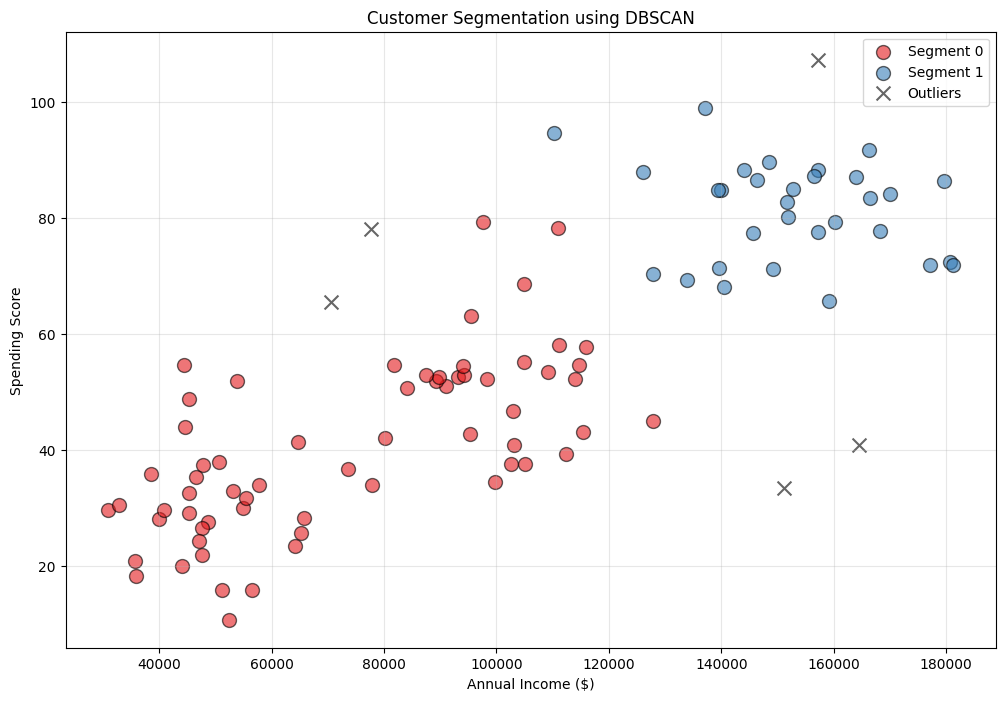


CUSTOMER SEGMENTS SUMMARY

Segment 0:
  Count: 64
  Avg Income: $73932.79
  Avg Spending: 40.69

Segment 1:
  Count: 31
  Avg Income: $152538.04
  Avg Spending: 81.13

Outliers:
  Count: 5
  Avg Income: $124195.49
  Avg Spending: 65.03

✓ DBSCAN CLUSTERING COMPLETE!


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# Function to plot k-distance graph
# This helps us choose the right epsilon value
def plot_k_distance_graph(X, k):
    """
    Plot k-distance graph to find optimal epsilon

    Parameters:
    X: Dataset (features)
    k: Number of neighbors (usually same as MinPts)
    """
    # Step 1: Fit NearestNeighbors model
    neigh = NearestNeighbors(n_neighbors=k)
    neigh.fit(X)

    # Step 2: Find k nearest neighbors for each point
    distances, _ = neigh.kneighbors(X)

    # Step 3: Sort distances (we want k-th neighbor distance)
    distances = np.sort(distances[:, k-1])

    # Step 4: Plot the k-distance graph
    plt.figure(figsize=(10, 6))
    plt.plot(distances)
    plt.xlabel('Points')
    plt.ylabel(f'{k}-th nearest neighbor distance')
    plt.title('K-distance Graph')
    plt.grid(True)
    plt.show()

# Generate sample data for demonstration
print("=" * 60)
print("DBSCAN CLUSTERING DEMONSTRATION")
print("=" * 60)

# Create synthetic dataset with clusters and noise
np.random.seed(42)

# Cluster 1: Around (2, 2)
cluster1 = np.random.randn(50, 2) * 0.5 + [2, 2]

# Cluster 2: Around (8, 8)
cluster2 = np.random.randn(50, 2) * 0.5 + [8, 8]

# Cluster 3: Around (2, 8)
cluster3 = np.random.randn(50, 2) * 0.5 + [2, 8]

# Noise points (outliers)
noise = np.random.uniform(0, 10, (10, 2))

# Combine all data
X = np.vstack([cluster1, cluster2, cluster3, noise])

print(f"\nDataset created:")
print(f"Total points: {len(X)}")
print(f"Cluster 1: 50 points around (2, 2)")
print(f"Cluster 2: 50 points around (8, 8)")
print(f"Cluster 3: 50 points around (2, 8)")
print(f"Noise: 10 random points")

# Step 1: Plot k-distance graph to find epsilon
print("\n" + "=" * 60)
print("STEP 1: FINDING OPTIMAL EPSILON")
print("=" * 60)
print("\nPlotting k-distance graph...")
print("Look for the 'elbow' point in the graph")
print("The y-value at the elbow is your optimal epsilon")

plot_k_distance_graph(X, k=5)

# Step 2: Apply DBSCAN clustering
print("\n" + "=" * 60)
print("STEP 2: APPLYING DBSCAN")
print("=" * 60)

# Parameters for DBSCAN
epsilon = 0.5  # Maximum distance between neighbors
min_samples = 5  # Minimum points to form a cluster

print(f"\nDBSCAN Parameters:")
print(f"Epsilon (ε): {epsilon}")
print(f"MinPts: {min_samples}")

# Create and fit DBSCAN model
dbscan = DBSCAN(eps=epsilon, min_samples=min_samples)
labels = dbscan.fit_predict(X)

# Step 3: Analyze results
print("\n" + "=" * 60)
print("STEP 3: RESULTS")
print("=" * 60)

# Count clusters (excluding noise which is labeled -1)
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print(f"\nNumber of clusters found: {n_clusters}")
print(f"Number of noise points: {n_noise}")

# Print cluster sizes
for cluster_id in set(labels):
    if cluster_id == -1:
        continue
    cluster_size = list(labels).count(cluster_id)
    print(f"Cluster {cluster_id}: {cluster_size} points")

# Step 4: Visualize clusters
print("\n" + "=" * 60)
print("STEP 4: VISUALIZATION")
print("=" * 60)

plt.figure(figsize=(12, 8))

# Plot each cluster with different color
unique_labels = set(labels)
colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels)))

for label, color in zip(unique_labels, colors):
    if label == -1:
        # Noise points in black
        color = 'black'
        marker = 'x'
        label_name = 'Noise'
    else:
        marker = 'o'
        label_name = f'Cluster {label}'

    # Get points belonging to this cluster
    class_member_mask = (labels == label)
    xy = X[class_member_mask]

    plt.scatter(xy[:, 0], xy[:, 1],
               c=[color],
               marker=marker,
               s=100,
               alpha=0.6,
               edgecolors='black',
               label=label_name)

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title(f'DBSCAN Clustering (ε={epsilon}, MinPts={min_samples})')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

# Step 5: Detailed explanation
print("\n" + "=" * 60)
print("HOW DBSCAN WORKS")
print("=" * 60)

print("""
1. For each point, find all neighbors within epsilon distance

2. Classify points:
   - Core Point: Has >= MinPts neighbors (including itself)
   - Border Point: Within epsilon of a core point, but not core
   - Noise Point: Neither core nor border (outlier)

3. Form clusters:
   - Start with a core point
   - Add all reachable core points to the cluster
   - Add border points connected to these core points
   - Repeat for all unvisited core points

4. Mark remaining points as noise

ADVANTAGES:
✓ Finds clusters of arbitrary shape
✓ Automatically detects outliers
✓ No need to specify number of clusters
✓ Works well with spatial data

DISADVANTAGES:
✗ Sensitive to epsilon and MinPts parameters
✗ Struggles with varying density clusters
✗ Not suitable for high-dimensional data
""")

# Example with real-world scenario
print("\n" + "=" * 60)
print("REAL-WORLD EXAMPLE: CUSTOMER SEGMENTATION")
print("=" * 60)

# Create customer data
np.random.seed(42)
customer_data = pd.DataFrame({
    'Annual_Income': np.concatenate([
        np.random.normal(50000, 10000, 30),  # Low income
        np.random.normal(100000, 15000, 30), # Medium income
        np.random.normal(150000, 20000, 30), # High income
        np.random.uniform(30000, 180000, 10) # Outliers
    ]),
    'Spending_Score': np.concatenate([
        np.random.normal(30, 10, 30),   # Low spenders
        np.random.normal(50, 10, 30),   # Medium spenders
        np.random.normal(80, 10, 30),   # High spenders
        np.random.uniform(10, 90, 10)   # Outliers
    ])
})

print("\nCustomer Dataset:")
print(customer_data.head())

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(customer_data)

# Apply DBSCAN
dbscan_customers = DBSCAN(eps=0.5, min_samples=5)
customer_labels = dbscan_customers.fit_predict(X_scaled)

# Add labels to dataframe
customer_data['Cluster'] = customer_labels

# Visualize customer segments
plt.figure(figsize=(12, 8))

for label in set(customer_labels):
    if label == -1:
        color = 'black'
        marker = 'x'
        label_name = 'Outliers'
    else:
        color = plt.cm.Set1(label)
        marker = 'o'
        label_name = f'Segment {label}'

    mask = customer_labels == label
    plt.scatter(customer_data[mask]['Annual_Income'],
               customer_data[mask]['Spending_Score'],
               c=[color],
               marker=marker,
               s=100,
               alpha=0.6,
               edgecolors='black',
               label=label_name)

plt.xlabel('Annual Income ($)')
plt.ylabel('Spending Score')
plt.title('Customer Segmentation using DBSCAN')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Summary statistics
print("\n" + "=" * 60)
print("CUSTOMER SEGMENTS SUMMARY")
print("=" * 60)

for label in set(customer_labels):
    if label == -1:
        segment_name = "Outliers"
    else:
        segment_name = f"Segment {label}"

    segment_data = customer_data[customer_data['Cluster'] == label]
    print(f"\n{segment_name}:")
    print(f"  Count: {len(segment_data)}")
    print(f"  Avg Income: ${segment_data['Annual_Income'].mean():.2f}")
    print(f"  Avg Spending: {segment_data['Spending_Score'].mean():.2f}")

print("\n" + "=" * 60)
print("✓ DBSCAN CLUSTERING COMPLETE!")
print("=" * 60)

DBSCAN: Customer Segmentation for a Retail Store

SCENARIO:
A retail store wants to understand its customers better. They have data on:
- How much each customer spends per visit (in dollars)
- How frequently they visit the store (visits per month)


RETAIL STORE: CUSTOMER SEGMENTATION USING DBSCAN

Customer Data:
Format: [Spending per visit ($), Visits per month]
----------------------------------------------------------------------
Customer  1: $ 5000 per visit, 50 visits/month
Customer  2: $ 5200 per visit, 48 visits/month
Customer  3: $ 4800 per visit, 52 visits/month
Customer  4: $ 1500 per visit, 10 visits/month
Customer  5: $ 1600 per visit, 12 visits/month
Customer  6: $ 1400 per visit,  9 visits/month
Customer  7: $ 3000 per visit, 25 visits/month
Customer  8: $ 3100 per visit, 27 visits/month
Customer  9: $ 2900 per visit, 24 visits/month
Customer 10: $ 8000 per visit,  5 visits/month
Customer 11: $  200 per visit,  2 visits/month

Total customers: 11

STEP 1: DATA STANDARDIZATION

Original data has different scales:
  Spending range: $200 - $8000
  Visits range: 2 - 52

After standardization, both features have:
  Mean ≈ 0, Standard deviation ≈ 1
✓ Data is now ready for DBSCAN

STEP 2: FINDING OPTIMAL EPSILON (ε)


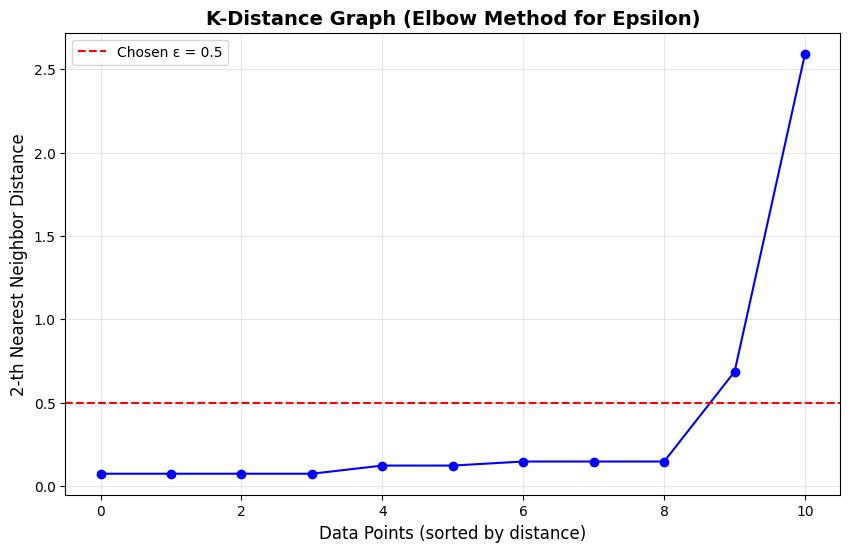


K-Distance Graph plotted!
Look for the 'elbow' point where the curve bends sharply
The y-value at the elbow is your optimal epsilon

✓ Based on the graph, we choose ε = 0.5

STEP 3: APPLYING DBSCAN CLUSTERING

DBSCAN Parameters:
  Epsilon (ε): 0.5
    → Maximum distance between two points to be neighbors
  MinPts: 2
    → Minimum points needed to form a dense region (cluster)

✓ DBSCAN clustering complete!

STEP 4: CLUSTERING RESULTS

Clusters found: 3
Outliers detected: 2

----------------------------------------------------------------------
CUSTOMER SEGMENTS:
----------------------------------------------------------------------

CLUSTER 0:
  Number of customers: 3
  Average spending per visit: $5000.00
  Average visits per month: 50.00
  Classification: 💎 LOYAL HIGH SPENDERS
  Customer IDs: [np.int64(1), np.int64(2), np.int64(3)]

CLUSTER 1:
  Number of customers: 3
  Average spending per visit: $1500.00
  Average visits per month: 10.33
  Classification: 👤 OCCASIONAL VISITORS
  C

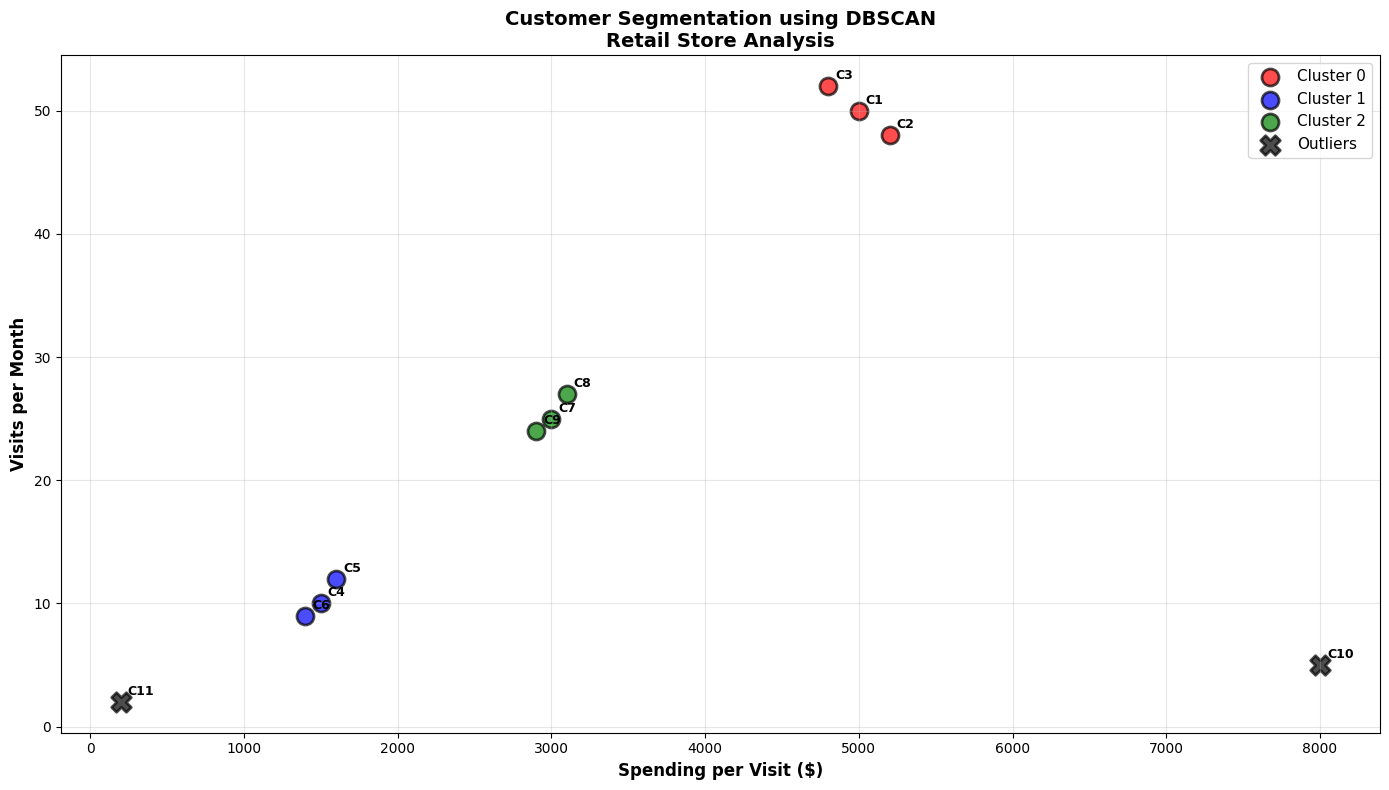


✓ Visualization saved: customer_segments.png

BUSINESS INSIGHTS & RECOMMENDATIONS

📊 CUSTOMER SEGMENTS IDENTIFIED:

1. LOYAL HIGH SPENDERS (Cluster with high spending + high visits)
   💡 Strategy:
   - VIP treatment and exclusive offers
   - Loyalty rewards program
   - Personal shopping assistance
   - Early access to new products

2. MODERATE SPENDERS (Middle ground customers)
   💡 Strategy:
   - Upselling opportunities
   - Bundle deals to increase spending
   - Frequency incentives to increase visits
   - Targeted promotions

3. OCCASIONAL VISITORS (Low spending + low visits)
   💡 Strategy:
   - Re-engagement campaigns
   - Special discounts to increase frequency
   - Email marketing with personalized offers
   - Referral programs

4. OUTLIERS (Unusual behavior)
   💡 Strategy:
   - Investigate individually
   - Rare high spenders: Special attention, concierge service
   - Very low engagement: Win-back campaigns or let go
   - May indicate data errors or unique circumstances

🎯 KEY

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

print("=" * 70)
print("RETAIL STORE: CUSTOMER SEGMENTATION USING DBSCAN")
print("=" * 70)

# Step 1: Prepare the customer data
# Each row: [Spending per visit ($), Visits per month]
data = np.array([
    [5000, 50], [5200, 48], [4800, 52],   # Loyal high spenders
    [1500, 10], [1600, 12], [1400, 9],    # Occasional visitors
    [3000, 25], [3100, 27], [2900, 24],   # Moderate spenders
    [8000, 5],                             # Outlier: rare but huge spender
    [200, 2],                              # Outlier: very low engagement
])

print("\nCustomer Data:")
print("Format: [Spending per visit ($), Visits per month]")
print("-" * 70)
for i, customer in enumerate(data):
    print(f"Customer {i+1:2d}: ${customer[0]:5.0f} per visit, {customer[1]:2.0f} visits/month")

print(f"\nTotal customers: {len(data)}")

# Step 2: Standardize the data
# Why? Because spending (in thousands) and visits (in tens) have different scales
# Standardization makes them comparable
print("\n" + "=" * 70)
print("STEP 1: DATA STANDARDIZATION")
print("=" * 70)

scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

print("\nOriginal data has different scales:")
print(f"  Spending range: ${data[:, 0].min():.0f} - ${data[:, 0].max():.0f}")
print(f"  Visits range: {data[:, 1].min():.0f} - {data[:, 1].max():.0f}")
print("\nAfter standardization, both features have:")
print(f"  Mean ≈ 0, Standard deviation ≈ 1")
print("✓ Data is now ready for DBSCAN")

# Step 3: Find optimal epsilon using k-distance graph
print("\n" + "=" * 70)
print("STEP 2: FINDING OPTIMAL EPSILON (ε)")
print("=" * 70)

# Calculate distances to k-th nearest neighbor
k = 2  # MinPts - 1
neigh = NearestNeighbors(n_neighbors=k)
neigh.fit(data_scaled)
distances, _ = neigh.kneighbors(data_scaled)

# Sort distances
distances = np.sort(distances[:, k-1])

# Plot k-distance graph
plt.figure(figsize=(10, 6))
plt.plot(distances, marker='o', linestyle='-', color='blue')
plt.xlabel('Data Points (sorted by distance)', fontsize=12)
plt.ylabel(f'{k}-th Nearest Neighbor Distance', fontsize=12)
plt.title('K-Distance Graph (Elbow Method for Epsilon)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.axhline(y=0.5, color='red', linestyle='--', label='Chosen ε = 0.5')
plt.legend()
plt.show()

print("\nK-Distance Graph plotted!")
print("Look for the 'elbow' point where the curve bends sharply")
print("The y-value at the elbow is your optimal epsilon")
print("\n✓ Based on the graph, we choose ε = 0.5")

# Step 4: Apply DBSCAN clustering
print("\n" + "=" * 70)
print("STEP 3: APPLYING DBSCAN CLUSTERING")
print("=" * 70)

# DBSCAN parameters
epsilon = 0.5      # Maximum distance between neighbors
min_samples = 2    # Minimum points to form a cluster

print(f"\nDBSCAN Parameters:")
print(f"  Epsilon (ε): {epsilon}")
print(f"    → Maximum distance between two points to be neighbors")
print(f"  MinPts: {min_samples}")
print(f"    → Minimum points needed to form a dense region (cluster)")

# Fit DBSCAN
dbscan = DBSCAN(eps=epsilon, min_samples=min_samples)
labels = dbscan.fit_predict(data_scaled)

# Add labels to original data
data_with_labels = np.column_stack((data, labels))

print("\n✓ DBSCAN clustering complete!")

# Step 5: Analyze results
print("\n" + "=" * 70)
print("STEP 4: CLUSTERING RESULTS")
print("=" * 70)

# Count clusters and noise
unique_labels = set(labels)
n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
n_noise = list(labels).count(-1)

print(f"\nClusters found: {n_clusters}")
print(f"Outliers detected: {n_noise}")

# Analyze each cluster
print("\n" + "-" * 70)
print("CUSTOMER SEGMENTS:")
print("-" * 70)

for label in unique_labels:
    if label == -1:
        segment_name = "OUTLIERS (Unusual Behavior)"
    else:
        segment_name = f"CLUSTER {label}"

    # Get customers in this segment
    mask = labels == label
    segment_customers = data[mask]

    print(f"\n{segment_name}:")
    print(f"  Number of customers: {len(segment_customers)}")

    if len(segment_customers) > 0:
        avg_spending = segment_customers[:, 0].mean()
        avg_visits = segment_customers[:, 1].mean()
        print(f"  Average spending per visit: ${avg_spending:.2f}")
        print(f"  Average visits per month: {avg_visits:.2f}")

        # Classify the segment
        if label != -1:
            if avg_spending > 4000 and avg_visits > 40:
                classification = "💎 LOYAL HIGH SPENDERS"
            elif avg_spending > 2500 and avg_visits > 20:
                classification = "⭐ MODERATE SPENDERS"
            elif avg_spending < 2000 and avg_visits < 15:
                classification = "👤 OCCASIONAL VISITORS"
            else:
                classification = "📊 MIXED SEGMENT"
            print(f"  Classification: {classification}")

        # Show customer IDs
        customer_ids = np.where(mask)[0] + 1
        print(f"  Customer IDs: {list(customer_ids)}")

# Step 6: Visualize clusters
print("\n" + "=" * 70)
print("STEP 5: VISUALIZATION")
print("=" * 70)

plt.figure(figsize=(14, 8))

# Define colors for clusters
colors = ['red', 'blue', 'green', 'orange', 'purple']

for label in unique_labels:
    if label == -1:
        # Outliers in black with 'X' marker
        color = 'black'
        marker = 'X'
        size = 200
        label_name = 'Outliers'
    else:
        # Clusters with different colors
        color = colors[label % len(colors)]
        marker = 'o'
        size = 150
        label_name = f'Cluster {label}'

    # Get points for this cluster
    mask = labels == label
    cluster_points = data[mask]

    plt.scatter(cluster_points[:, 0], cluster_points[:, 1],
               c=color, marker=marker, s=size,
               alpha=0.7, edgecolors='black', linewidth=2,
               label=label_name)

    # Add customer numbers
    for i, (x, y) in enumerate(cluster_points):
        customer_id = np.where((data[:, 0] == x) & (data[:, 1] == y))[0][0] + 1
        plt.annotate(f'C{customer_id}', (x, y),
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=9, fontweight='bold')

plt.xlabel('Spending per Visit ($)', fontsize=12, fontweight='bold')
plt.ylabel('Visits per Month', fontsize=12, fontweight='bold')
plt.title('Customer Segmentation using DBSCAN\nRetail Store Analysis',
         fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

print("\n✓ Visualization saved: customer_segments.png")

# Step 7: Business insights and recommendations
print("\n" + "=" * 70)
print("BUSINESS INSIGHTS & RECOMMENDATIONS")
print("=" * 70)

print("""
📊 CUSTOMER SEGMENTS IDENTIFIED:

1. LOYAL HIGH SPENDERS (Cluster with high spending + high visits)
   💡 Strategy:
   - VIP treatment and exclusive offers
   - Loyalty rewards program
   - Personal shopping assistance
   - Early access to new products

2. MODERATE SPENDERS (Middle ground customers)
   💡 Strategy:
   - Upselling opportunities
   - Bundle deals to increase spending
   - Frequency incentives to increase visits
   - Targeted promotions

3. OCCASIONAL VISITORS (Low spending + low visits)
   💡 Strategy:
   - Re-engagement campaigns
   - Special discounts to increase frequency
   - Email marketing with personalized offers
   - Referral programs

4. OUTLIERS (Unusual behavior)
   💡 Strategy:
   - Investigate individually
   - Rare high spenders: Special attention, concierge service
   - Very low engagement: Win-back campaigns or let go
   - May indicate data errors or unique circumstances

🎯 KEY TAKEAWAYS:
✓ DBSCAN successfully identified natural customer groups
✓ No need to pre-specify number of segments
✓ Automatically detected unusual customers (outliers)
✓ Can now create targeted marketing strategies for each segment
✓ Better resource allocation based on customer value
""")

# Step 8: Detailed customer report
print("\n" + "=" * 70)
print("DETAILED CUSTOMER REPORT")
print("=" * 70)

print("\n{:<12} {:<20} {:<15} {:<10}".format(
    "Customer", "Spending/Visit", "Visits/Month", "Segment"))
print("-" * 70)

for i, (customer, label) in enumerate(zip(data, labels)):
    if label == -1:
        segment = "Outlier"
    else:
        segment = f"Cluster {label}"

    print("{:<12} ${:<19.2f} {:<15.0f} {:<10}".format(
        f"Customer {i+1}", customer[0], customer[1], segment))

print("\n" + "=" * 70)
print("✓ CUSTOMER SEGMENTATION ANALYSIS COMPLETE!")
print("=" * 70)

print("\n📈 NEXT STEPS:")
print("1. Validate segments with business team")
print("2. Create targeted marketing campaigns for each segment")
print("3. Monitor customer movement between segments over time")
print("4. Calculate ROI for each segment")
print("5. Adjust strategies based on segment performance")